# Testbench

Loads exported network, the LR seed or a network the engine wrote during
evolution, simulates it on the attack set, and reports firing behaviour, key
rank, and disclosure.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import sca

H5_PATH  = "../modulated_dataset/aes_hd_snn_ready.h5"
PLOT_DIR = "../modulated_dataset/plots/validation"
BASENAME = "evaluate-network-csvs/best_network"
os.makedirs(PLOT_DIR, exist_ok=True)

net = sca.load_network(BASENAME)
print(f"{net['num_lif']} neurons ({net['num_hidden']} hidden), {net['num_synapses']} synapses")

9 neurons (0 hidden), 116 synapses


In [2]:
X_atk, y_atk, ct_atk, meta = sca.load_h5(H5_PATH, "Attack_traces")
X_prof, y_prof, _, _ = sca.load_h5(H5_PATH, "Profiling_traces")
ct_hi, ct_lo, true_k = meta

counts = sca.spike_counts(net, X_atk)
logp = sca.log_proba(counts)
rank, rec, ge, axis, disc = sca.guessing_entropy(logp, ct_atk, meta)

## Diagnostics

Predicted distribution vs true distribution shows where the network puts its
mass. Dead outputs (a class that never wins) flatten part of the likelihood and
hurt the attack.


In [3]:
acc = (counts.argmax(1) == y_atk).mean()
print("spikes/trace:", round(counts.sum(1).mean(), 2))
print("dead outputs:", int((counts.sum(0) == 0).sum()), "/ 9")
print("predicted dist:", np.bincount(counts.argmax(1), minlength=9))
print("true dist:     ", np.bincount(y_atk, minlength=9))
print("accuracy:", round(float(acc), 4), "(uniform 0.1111)")
print(f"recovered {rec} (true {true_k}), rank {rank}, disclosure {disc}")

spikes/trace: 17.79
dead outputs: 0 / 9
predicted dist: [4897  859   44   11   77  177  859 1484 1592]
true dist:      [  41  316 1097 2199 2742 2159 1095  315   36]
accuracy: 0.0296 (uniform 0.1111)
recovered 166 (true 166), rank 0, disclosure 3390


## Cross-check against the C engine


In [4]:
cp = sca.spike_counts(net, X_prof)
p = (cp + sca.ALPHA) / (cp.sum(1, keepdims=True) + sca.NUM_OUTPUTS * sca.ALPHA)
ll = np.log(p[np.arange(len(y_prof)), y_prof] + 1e-9)
gen0 = np.mean([ll[y_prof == c].mean() for c in range(9) if (y_prof == c).any()]) \
       - 1e-7 * (net["num_synapses"] + net["num_lif"])
print("predicted gen-0 fitness:", round(float(gen0), 4))

predicted gen-0 fitness: -2.1769


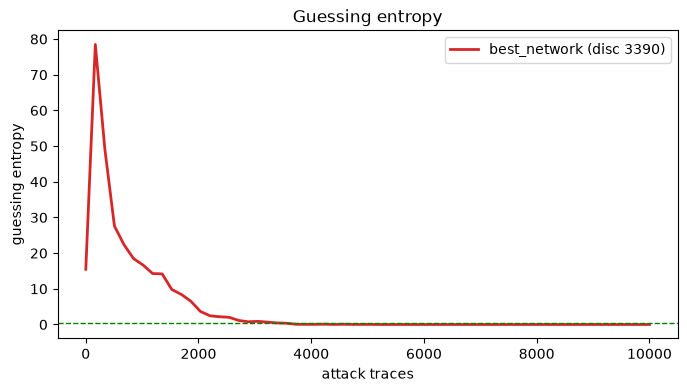

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(axis, ge, color="#d62728", lw=2, label=f"{os.path.basename(BASENAME)} (disc {disc})")
ax.axhline(0.5, color="green", ls="--", lw=1)
ax.set_xlabel("attack traces"); ax.set_ylabel("guessing entropy")
ax.set_title("Guessing entropy"); ax.legend()
fig.savefig(os.path.join(PLOT_DIR, "09_testbench_ge.png"), dpi=120)
plt.show()